In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = '/content/drive/MyDrive/DATA BASE/northstar_dataset/'

drivers = pd.read_csv(path + 'drivers.csv')
hubs = pd.read_csv(path + 'hubs.csv')
customers = pd.read_csv(path + 'customers.csv')
orders = pd.read_csv(path + 'orders.csv')
vehicles = pd.read_csv(path + 'vehicles.csv')
deliveries = pd.read_csv(path + 'deliveries.csv')
complaints = pd.read_csv(path + 'complaints.csv')
app_events = pd.read_csv(path + 'app_events.csv')
incidents = pd.read_csv(path + 'incidents.csv')

print("✅ All files loaded!")

✅ All files loaded!


delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


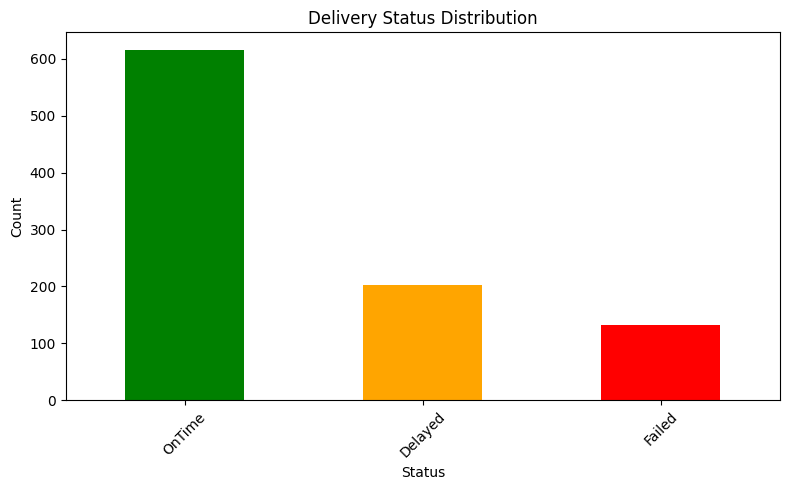

In [3]:
status_counts = deliveries['delivery_status'].value_counts()
print(status_counts)

plt.figure(figsize=(8,5))
colors = ['green', 'orange', 'red']
status_counts.plot(kind='bar', color=colors)
plt.title('Delivery Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pickup_zone
RiverSide    14
Central      11
EAST         11
CENTRAL      11
Ctr          11
South        10
East          8
Airport       8
north         8
North         7
WEST          7
NORTH         7
West          7
SOUTH         4
AIRPORT       4
Riverside     4
Name: count, dtype: int64


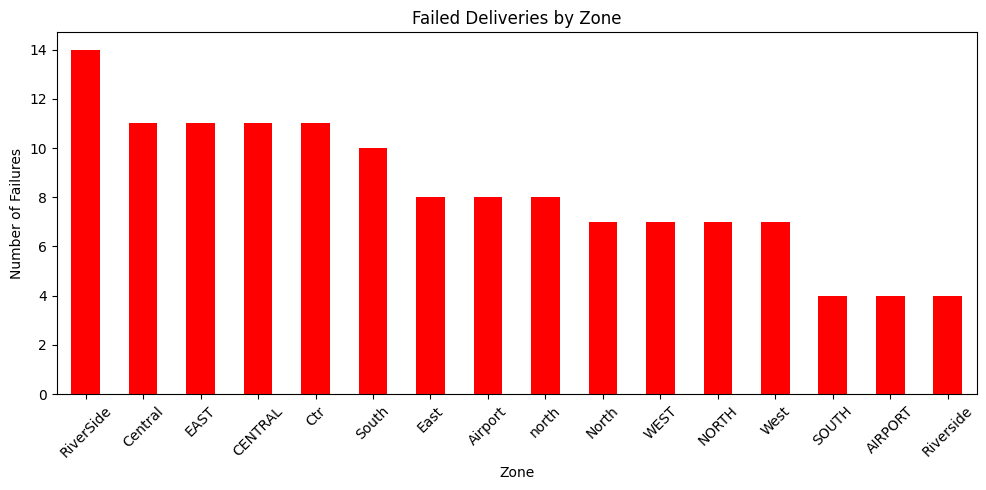

In [4]:
merged = deliveries.merge(orders, on='order_id')
failed = merged[merged['delivery_status'] == 'Failed']
failed_by_zone = failed['pickup_zone'].value_counts()

print(failed_by_zone)

plt.figure(figsize=(10,5))
failed_by_zone.plot(kind='bar', color='red')
plt.title('Failed Deliveries by Zone')
plt.xlabel('Zone')
plt.ylabel('Number of Failures')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

driver_id
D127    17
D087    16
D130    16
D108    15
D131    15
D069    14
D105    14
D028    13
D017    13
D008    12
Name: manual_route_override_count, dtype: int64


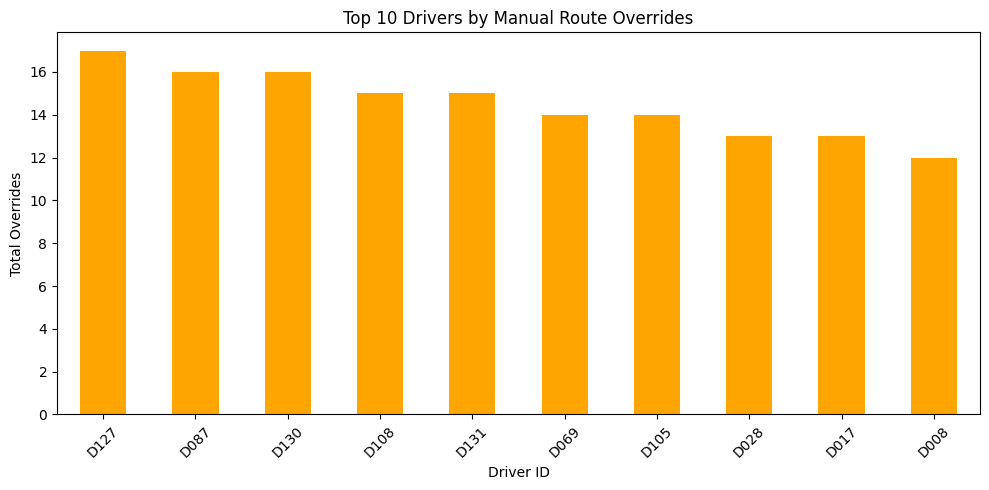

In [5]:
override_analysis = deliveries.groupby('driver_id')['manual_route_override_count'].sum()
top_overrides = override_analysis.sort_values(ascending=False).head(10)

print(top_overrides)

plt.figure(figsize=(10,5))
top_overrides.plot(kind='bar', color='orange')
plt.title('Top 10 Drivers by Manual Route Overrides')
plt.xlabel('Driver ID')
plt.ylabel('Total Overrides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64


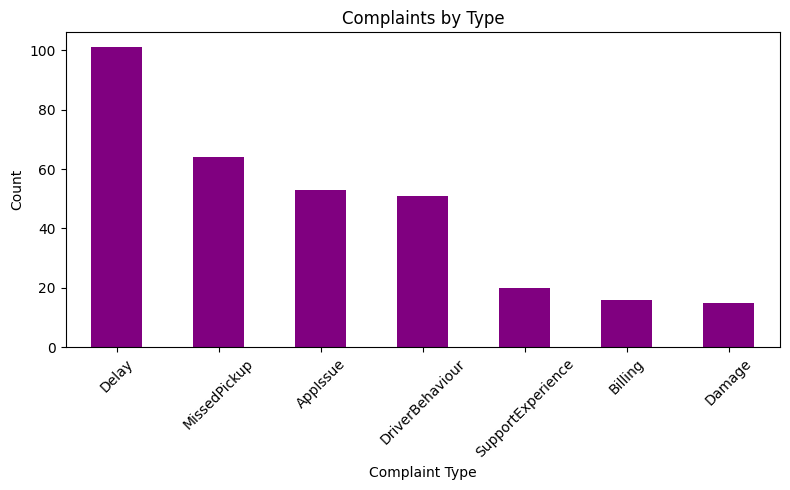

In [6]:
complaint_types = complaints['complaint_type'].value_counts()
print(complaint_types)

plt.figure(figsize=(8,5))
complaint_types.plot(kind='bar', color='purple')
plt.title('Complaints by Type')
plt.xlabel('Complaint Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

maintenance_status
Active       67
InRepair     36
Scheduled    17
Name: count, dtype: int64


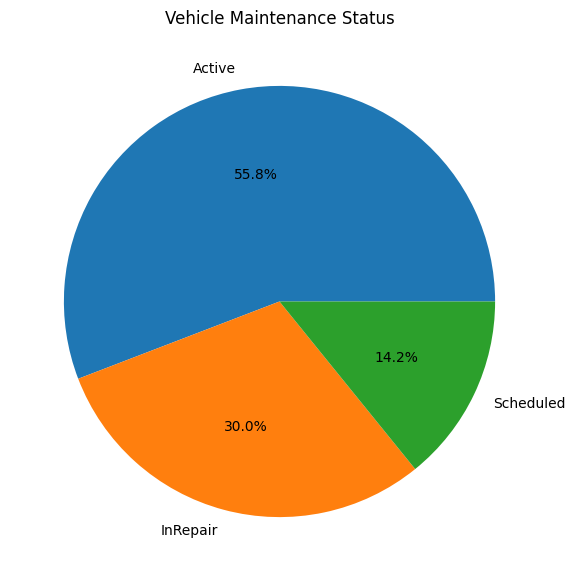

In [7]:
maintenance = vehicles['maintenance_status'].value_counts()
print(maintenance)

plt.figure(figsize=(7,7))
maintenance.plot(kind='pie', autopct='%1.1f%%')
plt.title('Vehicle Maintenance Status')
plt.ylabel('')
plt.show()

delivery_status
Delayed    13.138713
Failed     13.147955
OnTime     12.678052
Name: fuel_or_charge_cost, dtype: float64


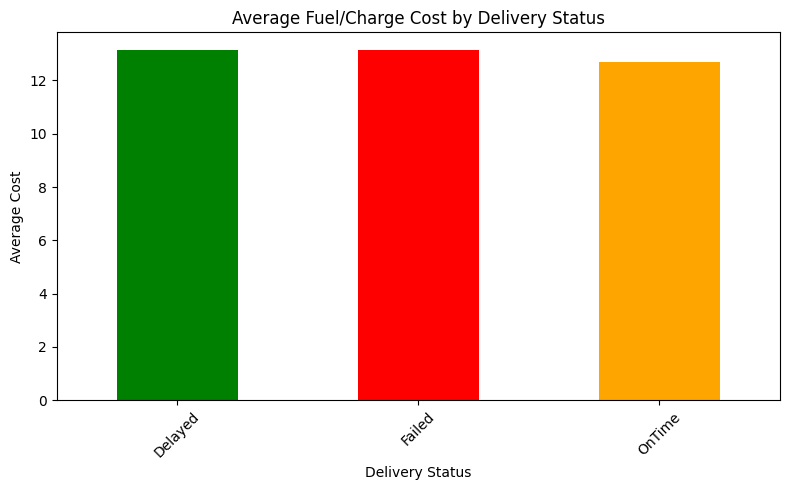

In [8]:
cost_by_status = deliveries.groupby('delivery_status')['fuel_or_charge_cost'].mean()
print(cost_by_status)

plt.figure(figsize=(8,5))
cost_by_status.plot(kind='bar', color=['green','red','orange'])
plt.title('Average Fuel/Charge Cost by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Cost')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64


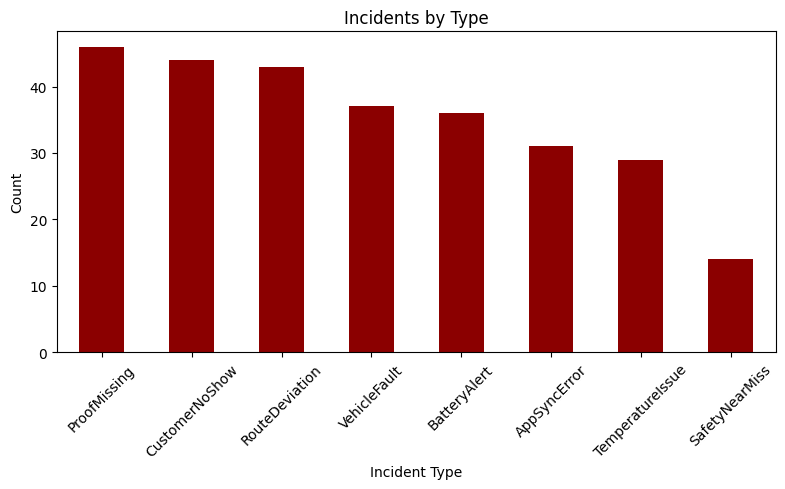

In [9]:
incident_types = incidents['incident_type'].value_counts()
print(incident_types)

plt.figure(figsize=(8,5))
incident_types.plot(kind='bar', color='darkred')
plt.title('Incidents by Type')
plt.xlabel('Incident Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

delivery_status
Delayed    3.114975
Failed     3.049313
OnTime     4.283273
Name: customer_rating_post_delivery, dtype: float64


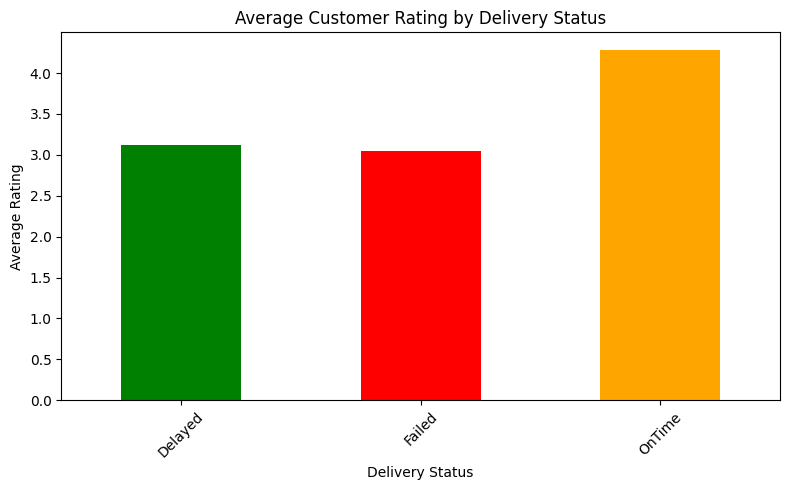

In [10]:
avg_rating = deliveries.groupby('delivery_status')['customer_rating_post_delivery'].mean()
print(avg_rating)

plt.figure(figsize=(8,5))
avg_rating.plot(kind='bar', color=['green','red','orange'])
plt.title('Average Customer Rating by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()